# Lung X-Ray Disease Classification
Classifications: 
* Normal
* Lung Opacity
* Viral Pneumonia

## 01. Setup 

In [1]:
import os
import gc
import json
import math
import random
import hashlib
import warnings
from pathlib import Path
from datetime import datetime

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from PIL import Image, ImageFile

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

In [5]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

2026-05-26 19:36:19.911595: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779824180.295486      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779824180.395717      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779824181.372179      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779824181.372235      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779824181.372238      23 computation_placer.cc:177] computation placer alr

In [6]:
warnings.filterwarnings("ignore")
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [7]:
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [8]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

os.environ["PYTHONHASHSEED"] = str(SEED)

## 02. Configuration 
Change MODEL_NAME to choose which model to run.

Options:
```text
 
  "custom_cnn"
  "efficientnetb0"
  "resnet50"
   
```

In [9]:
CONFIG = {
    # --------------------------------------------------------
    # Model selection
    # Options:
    #   "custom_cnn"
    #   "efficientnetb0"
    #   "resnet50"
    # --------------------------------------------------------
    "MODEL_NAME": "efficientnetb0",

    # Hardcoded Kaggle dataset path
    "DATA_DIR": "/kaggle/input/datasets/fatemehmehrparvar/lung-disease/Lung X-Ray Image/Lung X-Ray Image",

    # Image and training parameters
    "IMAGE_SIZE": (224, 224),
    "BATCH_SIZE": 16,
    "EPOCHS": 12,
    "FINE_TUNE_EPOCHS": 8,

    # Train / validation / test split
    "VALID_SIZE": 0.15,
    "TEST_SIZE": 0.15,

    # Optimization
    "LEARNING_RATE": 1e-4,
    "FINE_TUNE_LEARNING_RATE": 1e-5,

    # Classifier head
    "DROPOUT": 0.35,
    "DENSE_UNITS": 256,

    # Transfer learning options
    "DO_FINE_TUNE": True,
    "FINE_TUNE_LAST_N_LAYERS": 30,

    # Cleaning options
    "VALIDATE_IMAGES": True,
    "REMOVE_DUPLICATES": True,
    
    # Optional lightweight tuning
    "RUN_LIGHTWEIGHT_TUNING": False,
    "TUNING_EPOCHS": 3,

    # Output directory
    "OUTPUT_DIR": "/kaggle/working/lung_xray_project"
}

Path(CONFIG["OUTPUT_DIR"]).mkdir(parents=True, exist_ok=True)

CONFIG

{'MODEL_NAME': 'efficientnetb0',
 'DATA_DIR': '/kaggle/input/datasets/fatemehmehrparvar/lung-disease/Lung X-Ray Image/Lung X-Ray Image',
 'IMAGE_SIZE': (224, 224),
 'BATCH_SIZE': 16,
 'EPOCHS': 12,
 'FINE_TUNE_EPOCHS': 8,
 'VALID_SIZE': 0.15,
 'TEST_SIZE': 0.15,
 'LEARNING_RATE': 0.0001,
 'FINE_TUNE_LEARNING_RATE': 1e-05,
 'DROPOUT': 0.35,
 'DENSE_UNITS': 256,
 'DO_FINE_TUNE': True,
 'FINE_TUNE_LAST_N_LAYERS': 30,
 'VALIDATE_IMAGES': True,
 'REMOVE_DUPLICATES': True,
 'RUN_LIGHTWEIGHT_TUNING': False,
 'TUNING_EPOCHS': 3,
 'OUTPUT_DIR': '/kaggle/working/lung_xray_project'}

In [10]:
# Validate Dataset Path
DATA_DIR = Path(CONFIG["DATA_DIR"])

EXPECTED_CLASSES = [
    "Lung_Opacity",
    "Normal",
    "Viral Pneumonia"
]

if not DATA_DIR.exists():
    raise FileNotFoundError(f"DATA_DIR does not exist: {DATA_DIR}")

print("Dataset root:", DATA_DIR)
print("Dataset folders:")
print(os.listdir(DATA_DIR))

for class_name in EXPECTED_CLASSES:
    class_path = DATA_DIR / class_name

    if not class_path.exists():
        raise FileNotFoundError(
            f"Expected class folder not found: {class_path}"
        )

print("All expected class folders found.")

Dataset root: /kaggle/input/datasets/fatemehmehrparvar/lung-disease/Lung X-Ray Image/Lung X-Ray Image
Dataset folders:
['Normal', 'Lung_Opacity', 'Viral Pneumonia']
All expected class folders found.


## 03. Build Image Manifest

In [11]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

records = []

for class_name in EXPECTED_CLASSES:
    class_dir = DATA_DIR / class_name

    for file_path in class_dir.rglob("*"):
        if file_path.suffix.lower() in IMAGE_EXTENSIONS:
            records.append({
                "filepath": str(file_path),
                "label": class_name
            })

df = pd.DataFrame(records)

print("Total image files found:", len(df))
display(df.head())
display(df["label"].value_counts())

Total image files found: 3475


,filepath,label
0,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Lung_Opacity
1,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Lung_Opacity
2,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Lung_Opacity
3,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Lung_Opacity
4,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Lung_Opacity


label
Normal             1250
Lung_Opacity       1125
Viral Pneumonia    1100
Name: count, dtype: int64

## 04. Validate Images 

In [12]:
def validate_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except Exception:
        return False


if CONFIG["VALIDATE_IMAGES"]:
    df["is_valid"] = df["filepath"].apply(validate_image)

    invalid_df = df[df["is_valid"] == False]

    print("Invalid images found:", len(invalid_df))

    if len(invalid_df) > 0:
        display(invalid_df.head())

    df = df[df["is_valid"] == True].drop(columns=["is_valid"]).reset_index(drop=True)

print("Images after validation:", len(df))

Invalid images found: 0
Images after validation: 3475


## 05. Image Metadata 

In [13]:
def get_image_metadata(path):
    try:
        with Image.open(path) as img:
            return pd.Series({
                "width": img.width,
                "height": img.height,
                "mode": img.mode
            })
    except Exception:
        return pd.Series({
            "width": np.nan,
            "height": np.nan,
            "mode": None
        })


metadata_df = df["filepath"].apply(get_image_metadata)
df = pd.concat([df, metadata_df], axis=1)

display(df.head())
display(df.groupby("label")[["width", "height"]].describe())
display(df["mode"].value_counts())

,filepath,label,width,height,mode
0,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Lung_Opacity,299,299,RGB
1,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Lung_Opacity,299,299,RGB
2,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Lung_Opacity,299,299,RGB
3,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Lung_Opacity,299,299,RGB
4,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Lung_Opacity,299,299,RGB


width                                                 \
                  count   mean  std    min    25%    50%    75%    max   
label                                                                    
Lung_Opacity     1125.0  299.0  0.0  299.0  299.0  299.0  299.0  299.0   
Normal           1250.0  299.0  0.0  299.0  299.0  299.0  299.0  299.0   
Viral Pneumonia  1100.0  299.0  0.0  299.0  299.0  299.0  299.0  299.0   

                 height                                                 
                  count   mean  std    min    25%    50%    75%    max  
label                                                                   
Lung_Opacity     1125.0  299.0  0.0  299.0  299.0  299.0  299.0  299.0  
Normal           1250.0  299.0  0.0  299.0  299.0  299.0  299.0  299.0  
Viral Pneumonia  1100.0  299.0  0.0  299.0  299.0  299.0  299.0  299.0

mode
RGB    3475
Name: count, dtype: int64

## 06. Duplicate Detection and Removal 

In [14]:
def file_md5(path, block_size=65536):
    hasher = hashlib.md5()

    with open(path, "rb") as f:
        for block in iter(lambda: f.read(block_size), b""):
            hasher.update(block)

    return hasher.hexdigest()


df["file_hash"] = df["filepath"].apply(file_md5)

duplicate_count = df.duplicated("file_hash").sum()

print("Exact duplicate images found:", duplicate_count)

if duplicate_count > 0:
    duplicate_examples = (
        df[df.duplicated("file_hash", keep=False)]
        .sort_values("file_hash")
    )

    display(duplicate_examples.head(20))


if CONFIG["REMOVE_DUPLICATES"]:
    before = len(df)

    df = (
        df
        .drop_duplicates("file_hash", keep="first")
        .reset_index(drop=True)
    )

    after = len(df)

    print(f"Removed {before - after} duplicate images.")

print("Images after duplicate handling:", len(df))
display(df["label"].value_counts())

Exact duplicate images found: 5


,filepath,label,width,height,mode,file_hash
2420,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Viral Pneumonia,299,299,RGB,03be7856a3db3784f340718acae7802c
3446,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Viral Pneumonia,299,299,RGB,03be7856a3db3784f340718acae7802c
2695,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Viral Pneumonia,299,299,RGB,4e301f5187b2ef96b139446ebbb4aef8
2757,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Viral Pneumonia,299,299,RGB,4e301f5187b2ef96b139446ebbb4aef8
3109,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Viral Pneumonia,299,299,RGB,6ffad50473dc45727f6d50500b3f84ea
3275,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Viral Pneumonia,299,299,RGB,6ffad50473dc45727f6d50500b3f84ea
2707,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Viral Pneumonia,299,299,RGB,91ba812d0392195c63bc3ca86be8907e
3130,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Viral Pneumonia,299,299,RGB,91ba812d0392195c63bc3ca86be8907e
2517,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Viral Pneumonia,299,299,RGB,aae3e8d2598bf1469b319596bce678cc
3417,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Viral Pneumonia,299,299,RGB,aae3e8d2598bf1469b319596bce678cc


Removed 5 duplicate images.
Images after duplicate handling: 3470


label
Normal             1250
Lung_Opacity       1125
Viral Pneumonia    1095
Name: count, dtype: int64

## 07. Exploratory Data Analysis 

### 07a. Class Distribution 

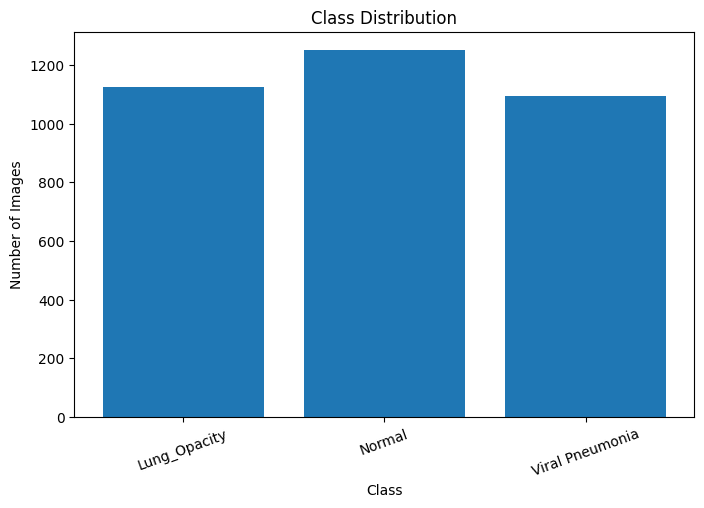

label
Lung_Opacity       1125
Normal             1250
Viral Pneumonia    1095
Name: count, dtype: int64

In [15]:
class_counts = df["label"].value_counts().reindex(EXPECTED_CLASSES)

plt.figure(figsize=(8, 5))
plt.bar(class_counts.index, class_counts.values)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=20)
plt.show()

display(class_counts)

### 07b. Image Size Distribution

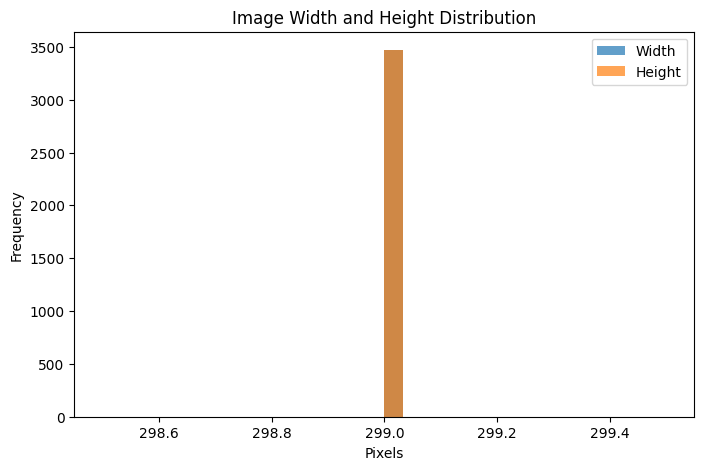

In [16]:
plt.figure(figsize=(8, 5))
plt.hist(df["width"], bins=30, alpha=0.7, label="Width")
plt.hist(df["height"], bins=30, alpha=0.7, label="Height")
plt.title("Image Width and Height Distribution")
plt.xlabel("Pixels")
plt.ylabel("Frequency")
plt.legend()
plt.show()

### 07c. Sample Images 

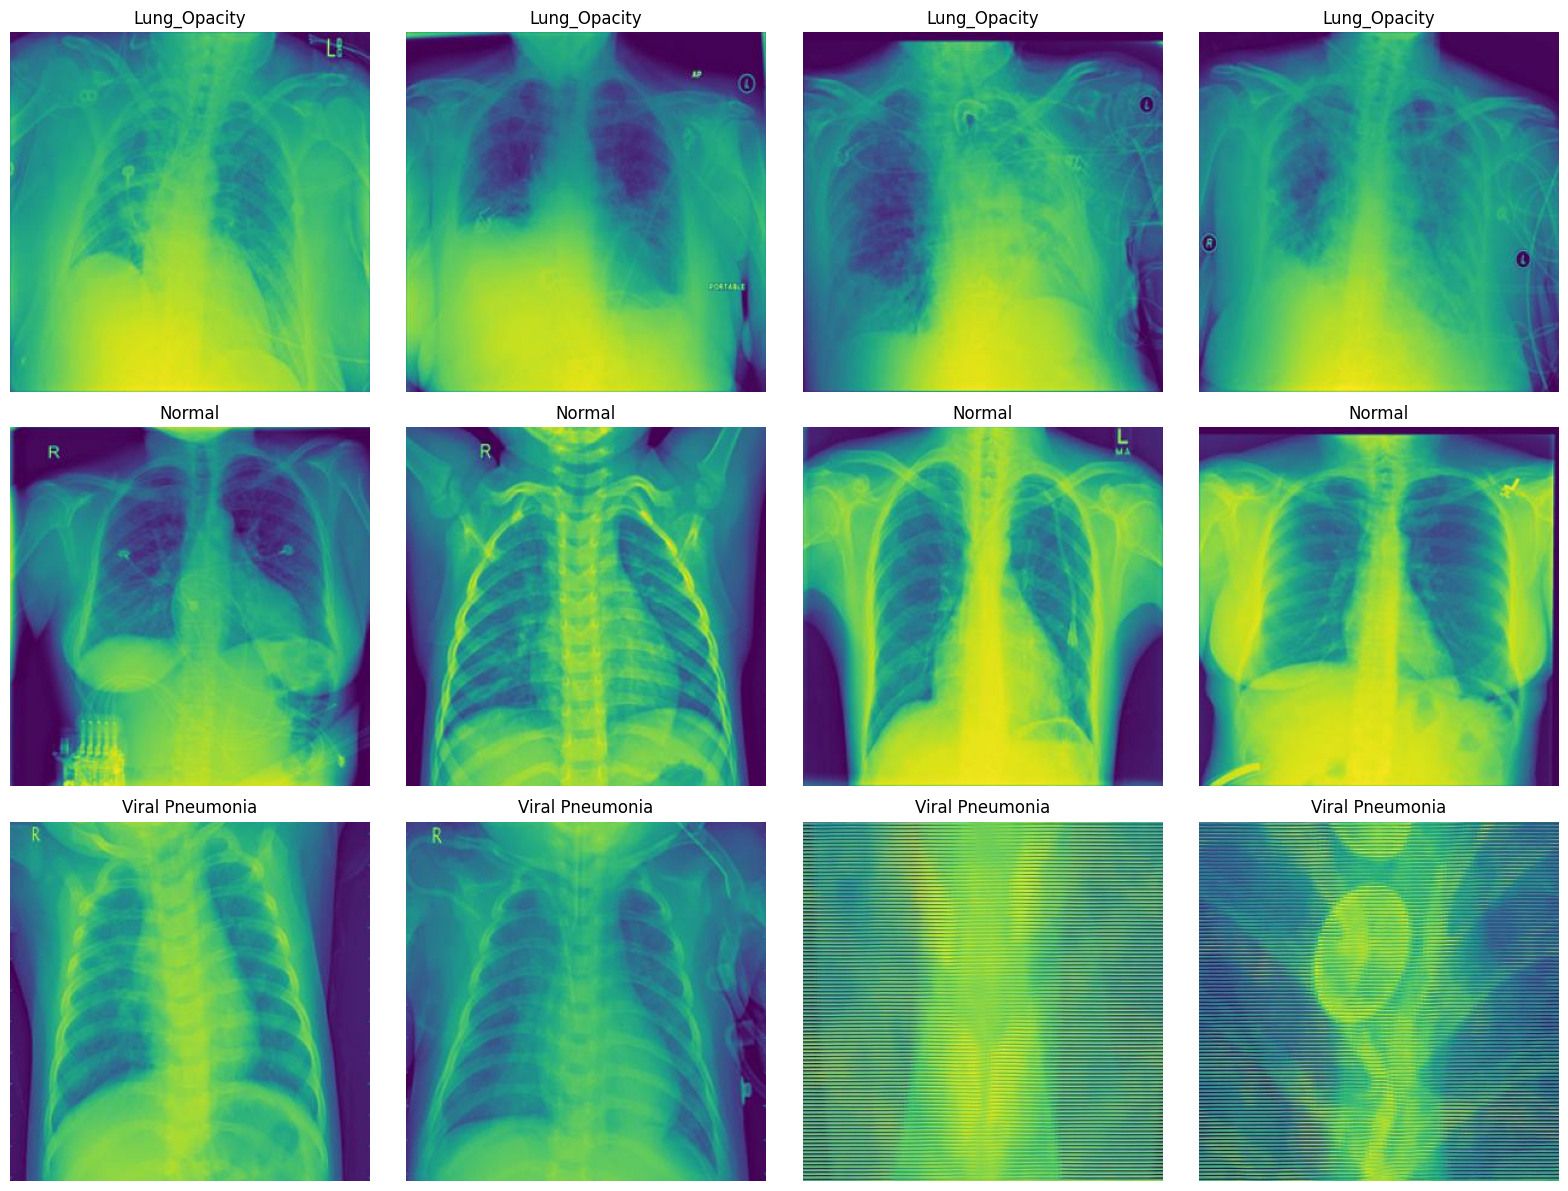

In [17]:
def show_samples(dataframe, class_names, samples_per_class=4):
    rows = len(class_names)
    cols = samples_per_class

    plt.figure(figsize=(cols * 4, rows * 4))

    plot_idx = 1

    for class_name in class_names:
        class_df = dataframe[dataframe["label"] == class_name]

        sample_df = class_df.sample(
            n=min(samples_per_class, len(class_df)),
            random_state=SEED
        )

        for _, row in sample_df.iterrows():
            img = Image.open(row["filepath"]).convert("RGB")

            plt.subplot(rows, cols, plot_idx)
            plt.imshow(img)
            plt.title(class_name)
            plt.axis("off")

            plot_idx += 1

    plt.tight_layout()
    plt.show()


show_samples(df, EXPECTED_CLASSES, samples_per_class=4)

## 08. Label Encoding 

In [18]:
class_names = sorted(df["label"].unique())

class_to_id = {
    class_name: idx
    for idx, class_name in enumerate(class_names)
}

id_to_class = {
    idx: class_name
    for class_name, idx in class_to_id.items()
}

df["label_id"] = df["label"].map(class_to_id)

NUM_CLASSES = len(class_names)

print("Class names:", class_names)
print("Class to ID mapping:", class_to_id)
print("Number of classes:", NUM_CLASSES)

display(df.head())

Class names: ['Lung_Opacity', 'Normal', 'Viral Pneumonia']
Class to ID mapping: {'Lung_Opacity': 0, 'Normal': 1, 'Viral Pneumonia': 2}
Number of classes: 3


,filepath,label,width,height,mode,file_hash,label_id
0,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Lung_Opacity,299,299,RGB,3d95207181d4c92619dce1677ba9fc87,0
1,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Lung_Opacity,299,299,RGB,e8a9768f9a1bb721601e67d972c6e8d5,0
2,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Lung_Opacity,299,299,RGB,0c01586302c5b44db53622304a6a37e5,0
3,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Lung_Opacity,299,299,RGB,f43ab9211611b3ac3413dd465be11de9,0
4,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Lung_Opacity,299,299,RGB,5820e7550510823a21571997982af669,0


## 09. Stratified Train / Validation / Test Split 

In [19]:
test_size = CONFIG["TEST_SIZE"]
valid_size = CONFIG["VALID_SIZE"]

train_df, temp_df = train_test_split(
    df,
    test_size=test_size + valid_size,
    stratify=df["label_id"],
    random_state=SEED
)

relative_valid_size = valid_size / (test_size + valid_size)

valid_df, test_df = train_test_split(
    temp_df,
    test_size=1 - relative_valid_size,
    stratify=temp_df["label_id"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train images:", len(train_df))
print("Validation images:", len(valid_df))
print("Test images:", len(test_df))

print("\nTrain distribution:")
display(train_df["label"].value_counts(normalize=True))

print("\nValidation distribution:")
display(valid_df["label"].value_counts(normalize=True))

print("\nTest distribution:")
display(test_df["label"].value_counts(normalize=True))

Train images: 2429
Validation images: 520
Test images: 521

Train distribution:


label
Normal             0.360231
Lung_Opacity       0.324413
Viral Pneumonia    0.315356
Name: proportion, dtype: float64


Validation distribution:


label
Normal             0.359615
Lung_Opacity       0.323077
Viral Pneumonia    0.317308
Name: proportion, dtype: float64


Test distribution:


label
Normal             0.360845
Lung_Opacity       0.324376
Viral Pneumonia    0.314779
Name: proportion, dtype: float64

## 10. Class Weights 

In [20]:
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label_id"]),
    y=train_df["label_id"]
)

class_weights = {
    int(class_id): float(weight)
    for class_id, weight in zip(np.unique(train_df["label_id"]), class_weights_array)
}

class_weights

{0: 1.0274957698815568, 1: 0.9253333333333333, 2: 1.057006092254134}

## 11. TensorFlow Dataset Pipeline

In [21]:
IMAGE_SIZE = CONFIG["IMAGE_SIZE"]
BATCH_SIZE = CONFIG["BATCH_SIZE"]
AUTOTUNE = tf.data.AUTOTUNE


def decode_and_resize_image(path, label):
    image_bytes = tf.io.read_file(path)

    image = tf.io.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMAGE_SIZE)
    image = tf.cast(image, tf.float32)

    # EfficientNetB0 expects float images and handles preprocessing internally.
    # ResNet50 expects images preprocessed with its own preprocess_input function.
    if CONFIG["MODEL_NAME"] == "resnet50":
        image = keras.applications.resnet50.preprocess_input(image)

    return image, label


def make_dataset(dataframe, shuffle=False):
    paths = dataframe["filepath"].values
    labels = dataframe["label_id"].values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    ds = ds.map(
        decode_and_resize_image,
        num_parallel_calls=AUTOTUNE
    )

    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)

    return ds


train_ds = make_dataset(train_df, shuffle=True)
valid_ds = make_dataset(valid_df, shuffle=False)
test_ds = make_dataset(test_df, shuffle=False)

for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

I0000 00:00:1779824237.740739      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Image batch shape: (16, 224, 224, 3)
Label batch shape: (16,)


## 12. Data Augmentation 

In [22]:
data_augmentation = keras.Sequential(
    [
        layers.RandomRotation(0.03),
        layers.RandomZoom(0.08),
        layers.RandomTranslation(0.04, 0.04),
        layers.RandomContrast(0.08),
    ],
    name="data_augmentation"
)

## 13. Model Builders 

In [23]:
def build_custom_cnn(input_shape, num_classes, dropout=0.35, dense_units=256):
    inputs = keras.Input(shape=input_shape)

    x = data_augmentation(inputs)
    x = layers.Rescaling(1.0 / 255.0)(x)

    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="custom_cnn"
    )

    return model


def build_transfer_model(
    model_name,
    input_shape,
    num_classes,
    dropout=0.35,
    dense_units=256
):
    inputs = keras.Input(shape=input_shape)

    x = data_augmentation(inputs)

    if model_name == "efficientnetb0":
        base_model = keras.applications.EfficientNetB0(
            include_top=False,
            weights="imagenet",
            input_shape=input_shape
        )

    elif model_name == "resnet50":
        base_model = keras.applications.ResNet50(
            include_top=False,
            weights="imagenet",
            input_shape=input_shape
        )

    else:
        raise ValueError(f"Unsupported transfer model: {model_name}")

    base_model.trainable = False

    x = base_model(x, training=False)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name=model_name
    )

    return model


def build_model_from_config(config):
    model_name = config["MODEL_NAME"]
    input_shape = (*config["IMAGE_SIZE"], 3)

    if model_name == "custom_cnn":
        model = build_custom_cnn(
            input_shape=input_shape,
            num_classes=NUM_CLASSES,
            dropout=config["DROPOUT"],
            dense_units=config["DENSE_UNITS"]
        )

    elif model_name in ["efficientnetb0", "resnet50"]:
        model = build_transfer_model(
            model_name=model_name,
            input_shape=input_shape,
            num_classes=NUM_CLASSES,
            dropout=config["DROPOUT"],
            dense_units=config["DENSE_UNITS"]
        )

    else:
        raise ValueError(
            "CONFIG['MODEL_NAME'] must be one of: "
            "'custom_cnn', 'efficientnetb0', 'resnet50'"
        )

    return model

## 14. Build and Compile Model

In [24]:
model = build_model_from_config(CONFIG)

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=CONFIG["LEARNING_RATE"]
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,302 (16.71 MB)

 Trainable params: 329,219 (1.26 MB)

 Non-trainable params: 4,050,083 (15.45 MB)

## 15. Optional Lightweight Tuning 
Do not use if you are trying to save on GPU compute time.  

In [25]:
def run_lightweight_tuning():
    search_space = [
        {
            "DROPOUT": 0.25,
            "DENSE_UNITS": 128,
            "LEARNING_RATE": 1e-4
        },
        {
            "DROPOUT": 0.35,
            "DENSE_UNITS": 256,
            "LEARNING_RATE": 1e-4
        },
        {
            "DROPOUT": 0.45,
            "DENSE_UNITS": 256,
            "LEARNING_RATE": 5e-5
        }
    ]

    results = []

    for i, params in enumerate(search_space, start=1):
        print("=" * 70)
        print(f"Tuning trial {i}/{len(search_space)}")
        print(params)

        trial_config = CONFIG.copy()
        trial_config.update(params)

        trial_model = build_model_from_config(trial_config)

        trial_model.compile(
            optimizer=keras.optimizers.Adam(
                learning_rate=trial_config["LEARNING_RATE"]
            ),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )

        trial_history = trial_model.fit(
            train_ds,
            validation_data=valid_ds,
            epochs=CONFIG["TUNING_EPOCHS"],
            class_weight=class_weights,
            verbose=1
        )

        best_val_acc = max(trial_history.history["val_accuracy"])
        best_val_loss = min(trial_history.history["val_loss"])

        results.append({
            **params,
            "best_val_accuracy": best_val_acc,
            "best_val_loss": best_val_loss
        })

        keras.backend.clear_session()
        gc.collect()

    results_df = pd.DataFrame(results).sort_values(
        by=["best_val_accuracy", "best_val_loss"],
        ascending=[False, True]
    )

    return results_df


if CONFIG["RUN_LIGHTWEIGHT_TUNING"]:
    tuning_results = run_lightweight_tuning()

    display(tuning_results)

    best_params = tuning_results.iloc[0].to_dict()

    CONFIG["DROPOUT"] = float(best_params["DROPOUT"])
    CONFIG["DENSE_UNITS"] = int(best_params["DENSE_UNITS"])
    CONFIG["LEARNING_RATE"] = float(best_params["LEARNING_RATE"])

    print("Updated CONFIG:")
    print(CONFIG)

    model = build_model_from_config(CONFIG)

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=CONFIG["LEARNING_RATE"]
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

## 16. Training Callbacks 

In [26]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_name = CONFIG["MODEL_NAME"]

checkpoint_path = f"{CONFIG['OUTPUT_DIR']}/{model_name}_best.keras"
csv_log_path = f"{CONFIG['OUTPUT_DIR']}/{model_name}_training_log.csv"

callbacks = [
    keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    keras.callbacks.CSVLogger(csv_log_path)
]

print("Checkpoint path:", checkpoint_path)
print("CSV log path:", csv_log_path)

Checkpoint path: /kaggle/working/lung_xray_project/efficientnetb0_best.keras
CSV log path: /kaggle/working/lung_xray_project/efficientnetb0_training_log.csv


## 17. Train Model 

In [27]:
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=CONFIG["EPOCHS"],
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/12


E0000 00:00:1779824255.959297      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/efficientnetb0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1779824259.281466      68 cuda_dnn.cc:529] Loaded cuDNN version 91002


151/152 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6373 - loss: 0.9040
Epoch 1: val_loss improved from inf to 0.41812, saving model to /kaggle/working/lung_xray_project/efficientnetb0_best.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 27s 71ms/step - accuracy: 0.6385 - loss: 0.9012 - val_accuracy: 0.8769 - val_loss: 0.4181 - learning_rate: 1.0000e-04
Epoch 2/12
151/152 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8333 - loss: 0.4367
Epoch 2: val_loss improved from 0.41812 to 0.33401, saving model to /kaggle/working/lung_xray_project/efficientnetb0_best.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - accuracy: 0.8333 - loss: 0.4368 - val_accuracy: 0.8846 - val_loss: 0.3340 - learning_rate: 1.0000e-04
Epoch 3/12
151/152 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8465 - loss: 0.4023
Epoch 3: val_loss improved from 0.33401 to 0.29489, saving model to /kaggle/working/lung_xray_project/efficientnetb0_best.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - accuracy: 0.8466 - loss: 0.4020 -

## 18. Plot Training Curves 

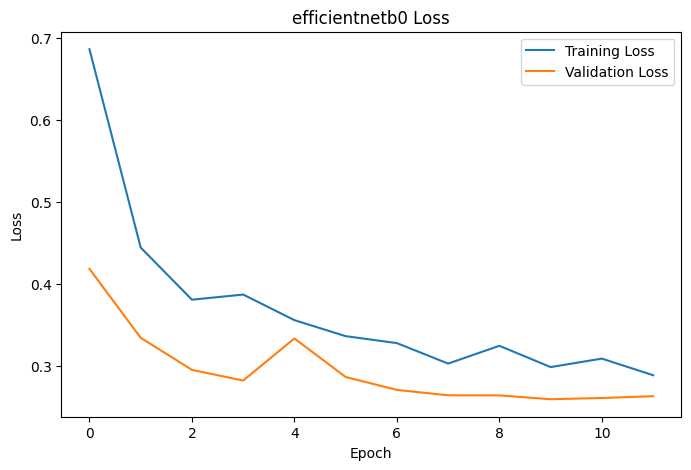

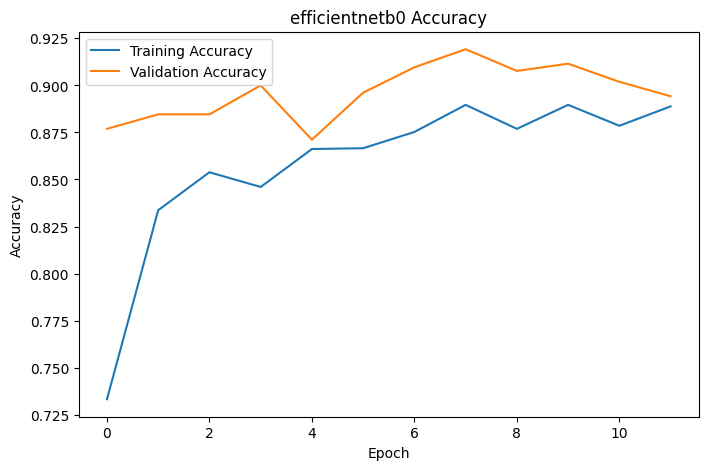

In [28]:
def plot_history(history, title_prefix="Model"):
    hist = pd.DataFrame(history.history)

    plt.figure(figsize=(8, 5))
    plt.plot(hist["loss"], label="Training Loss")
    plt.plot(hist["val_loss"], label="Validation Loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(hist["accuracy"], label="Training Accuracy")
    plt.plot(hist["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()


plot_history(history, title_prefix=CONFIG["MODEL_NAME"])

## 19. Optional Fine-Tuning

This only applies to:
```text

   efficientnetb0
   resnet50
 
```
It is skipped for:

```text

   custom_cnn
 
```

Base model found: efficientnetb0
Total base model layers: 238
Trainable base model layers: 23
Epoch 1/8


E0000 00:00:1779824375.246844      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/efficientnetb0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


151/152 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8760 - loss: 0.2862
Epoch 1: val_loss did not improve from 0.25903
152/152 ━━━━━━━━━━━━━━━━━━━━ 23s 64ms/step - accuracy: 0.8760 - loss: 0.2863 - val_accuracy: 0.9077 - val_loss: 0.2622 - learning_rate: 1.0000e-05
Epoch 2/8
151/152 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8956 - loss: 0.2646
Epoch 2: val_loss improved from 0.25903 to 0.25333, saving model to /kaggle/working/lung_xray_project/efficientnetb0_best.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - accuracy: 0.8956 - loss: 0.2649 - val_accuracy: 0.9154 - val_loss: 0.2533 - learning_rate: 1.0000e-05
Epoch 3/8
151/152 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8863 - loss: 0.2914
Epoch 3: val_loss did not improve from 0.25333
152/152 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.8864 - loss: 0.2912 - val_accuracy: 0.9135 - val_loss: 0.2613 - learning_rate: 1.0000e-05
Epoch 4/8
151/152 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8887 - loss: 0.2778
Epoch

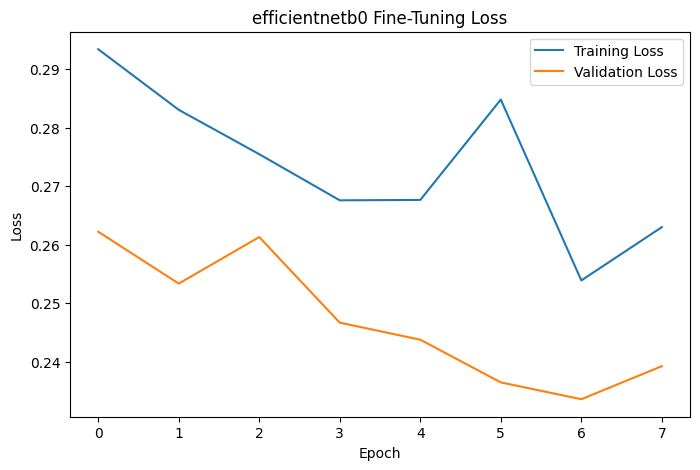

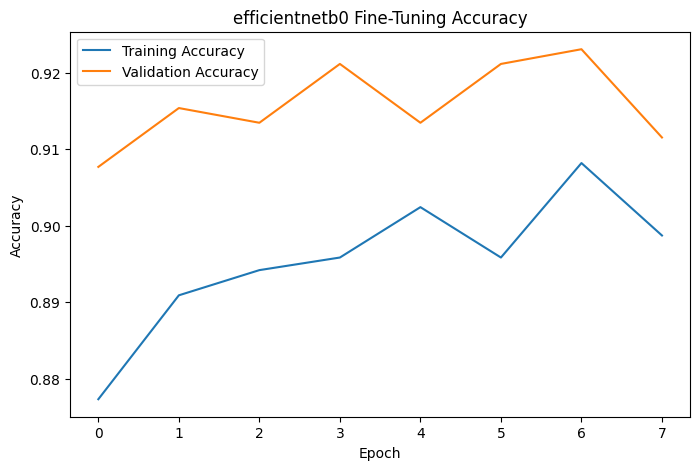

In [29]:
def fine_tune_transfer_model(model, config):
    model_name = config["MODEL_NAME"]

    if model_name == "custom_cnn":
        print("Skipping fine-tuning because custom_cnn has no pretrained base.")
        return model, None

    if not config["DO_FINE_TUNE"]:
        print("Fine-tuning disabled.")
        return model, None

    base_model = None

    for layer in model.layers:
        if isinstance(layer, keras.Model):
            if layer.name.lower() in ["efficientnetb0", "resnet50"]:
                base_model = layer
                break

    if base_model is None:
        print("Could not find pretrained base model. Skipping fine-tuning.")
        return model, None

    print("Base model found:", base_model.name)
    print("Total base model layers:", len(base_model.layers))

    base_model.trainable = True

    fine_tune_at = max(
        0,
        len(base_model.layers) - config["FINE_TUNE_LAST_N_LAYERS"]
    )

    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False

    # BatchNorm layers are commonly kept frozen during fine-tuning,
    # especially with smaller medical image datasets.
    for layer in base_model.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    trainable_base_layers = sum(
        1 for layer in base_model.layers if layer.trainable
    )

    print("Trainable base model layers:", trainable_base_layers)

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=config["FINE_TUNE_LEARNING_RATE"]
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    fine_tune_history = model.fit(
        train_ds,
        validation_data=valid_ds,
        epochs=config["FINE_TUNE_EPOCHS"],
        class_weight=class_weights,
        callbacks=callbacks,
        verbose=1
    )

    return model, fine_tune_history


model, fine_tune_history = fine_tune_transfer_model(model, CONFIG)

if fine_tune_history is not None:
    plot_history(
        fine_tune_history,
        title_prefix=f"{CONFIG['MODEL_NAME']} Fine-Tuning"
    )

## 20. Load Best Model 

In [30]:
best_model = keras.models.load_model(
    checkpoint_path,
    compile=False
)

best_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=CONFIG["FINE_TUNE_LEARNING_RATE"]
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Loaded best model from:")
print(checkpoint_path)

Loaded best model from:
/kaggle/working/lung_xray_project/efficientnetb0_best.keras


## 21. Evaluate on Test Set

In [31]:
test_loss, test_accuracy = best_model.evaluate(
    test_ds,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.9017 - loss: 0.2711
Test Loss: 0.29997000098228455
Test Accuracy: 0.8982725739479065


## 22. Generate Predictions 

In [32]:
y_true = test_df["label_id"].values

y_proba = best_model.predict(
    test_ds,
    verbose=1
)

y_pred = np.argmax(y_proba, axis=1)

print("y_true shape:", y_true.shape)
print("y_proba shape:", y_proba.shape)
print("y_pred shape:", y_pred.shape)

33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step
y_true shape: (521,)
y_proba shape: (521, 3)
y_pred shape: (521,)


## 23. Classification Reports 

In [33]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

display(report_df)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

,precision,recall,f1-score,support
Lung_Opacity,0.864407,0.905325,0.884393,169.000000
Normal,0.896552,0.829787,0.861878,188.000000
Viral Pneumonia,0.935294,0.969512,0.952096,164.000000
accuracy,0.898273,0.898273,0.898273,0.898273
macro avg,0.898751,0.901542,0.899456,521.000000
weighted avg,0.898320,0.898273,0.897580,521.000000


                 precision    recall  f1-score   support

   Lung_Opacity       0.86      0.91      0.88       169
         Normal       0.90      0.83      0.86       188
Viral Pneumonia       0.94      0.97      0.95       164

       accuracy                           0.90       521
      macro avg       0.90      0.90      0.90       521
   weighted avg       0.90      0.90      0.90       521



## 24. Confusion Matrix 

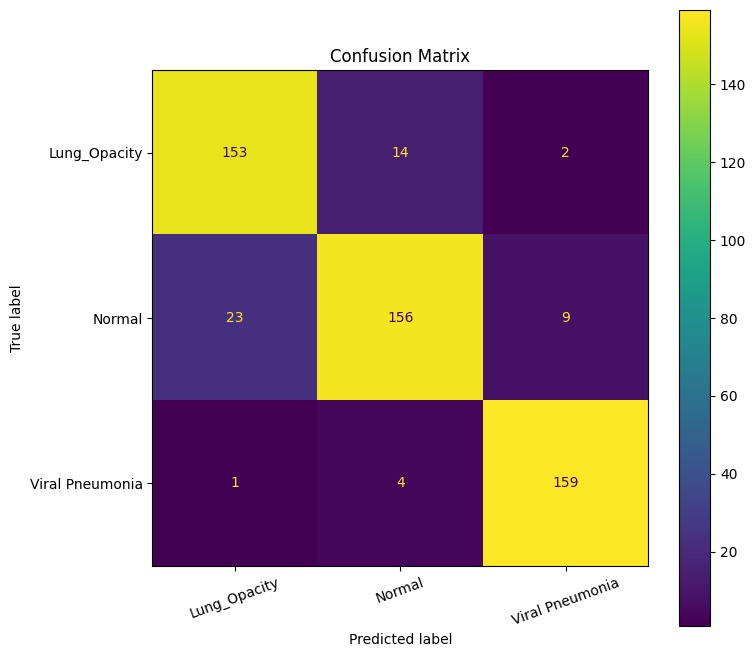

In [34]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, values_format="d")
plt.title("Confusion Matrix")
plt.xticks(rotation=20)
plt.show()

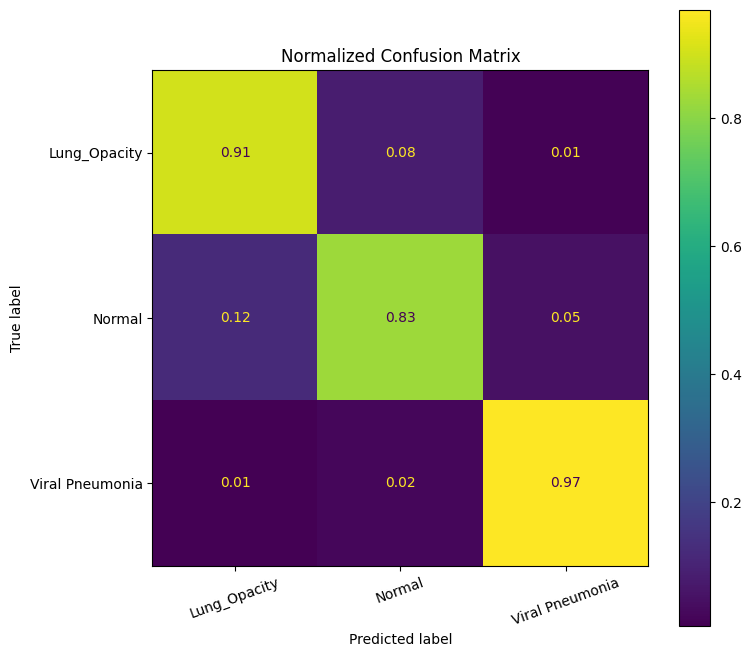

In [35]:
cm_norm = confusion_matrix(
    y_true,
    y_pred,
    normalize="true"
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, values_format=".2f")
plt.title("Normalized Confusion Matrix")
plt.xticks(rotation=20)
plt.show()

## 25. Multi-Class ROC AUC 

In [36]:
macro_roc_auc = None
weighted_roc_auc = None

try:
    macro_roc_auc = roc_auc_score(
        y_true,
        y_proba,
        multi_class="ovr",
        average="macro"
    )

    weighted_roc_auc = roc_auc_score(
        y_true,
        y_proba,
        multi_class="ovr",
        average="weighted"
    )

    print("Macro ROC-AUC:", macro_roc_auc)
    print("Weighted ROC-AUC:", weighted_roc_auc)

except Exception as e:
    print("Could not calculate ROC-AUC.")
    print(e)

Macro ROC-AUC: 0.9744504942686681
Weighted ROC-AUC: 0.9736990513389123


## 26. ROC Curves 

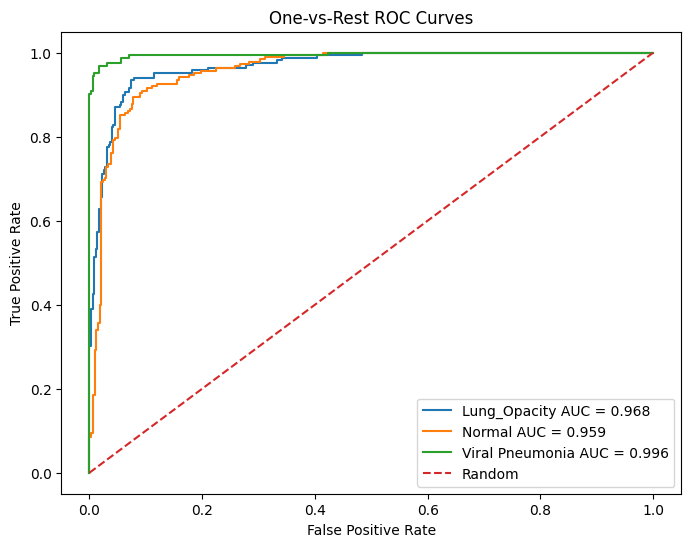

In [37]:
y_true_bin = label_binarize(
    y_true,
    classes=list(range(NUM_CLASSES))
)

plt.figure(figsize=(8, 6))

for class_idx, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(
        y_true_bin[:, class_idx],
        y_proba[:, class_idx]
    )

    class_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} AUC = {class_auc:.3f}"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.title("One-vs-Rest ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## 27. Save Metrics 

In [38]:
precision, recall, f1, support = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="weighted"
)

metrics = {
    "model_name": CONFIG["MODEL_NAME"],
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "weighted_precision": float(precision),
    "weighted_recall": float(recall),
    "weighted_f1": float(f1),
    "macro_roc_auc": None if macro_roc_auc is None else float(macro_roc_auc),
    "weighted_roc_auc": None if weighted_roc_auc is None else float(weighted_roc_auc),
    "class_names": class_names,
    "class_mapping": class_to_id,
    "config": CONFIG
}

metrics_path = f"{CONFIG['OUTPUT_DIR']}/{CONFIG['MODEL_NAME']}_metrics.json"

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=4)

print("Saved metrics to:")
print(metrics_path)

metrics

Saved metrics to:
/kaggle/working/lung_xray_project/efficientnetb0_metrics.json


{'model_name': 'efficientnetb0',
 'test_loss': 0.29997000098228455,
 'test_accuracy': 0.8982725739479065,
 'weighted_precision': 0.8983199715830337,
 'weighted_recall': 0.8982725527831094,
 'weighted_f1': 0.8975802101569785,
 'macro_roc_auc': 0.9744504942686681,
 'weighted_roc_auc': 0.9736990513389123,
 'class_names': ['Lung_Opacity', 'Normal', 'Viral Pneumonia'],
 'class_mapping': {'Lung_Opacity': 0, 'Normal': 1, 'Viral Pneumonia': 2},
 'config': {'MODEL_NAME': 'efficientnetb0',
  'DATA_DIR': '/kaggle/input/datasets/fatemehmehrparvar/lung-disease/Lung X-Ray Image/Lung X-Ray Image',
  'IMAGE_SIZE': (224, 224),
  'BATCH_SIZE': 16,
  'EPOCHS': 12,
  'FINE_TUNE_EPOCHS': 8,
  'VALID_SIZE': 0.15,
  'TEST_SIZE': 0.15,
  'LEARNING_RATE': 0.0001,
  'FINE_TUNE_LEARNING_RATE': 1e-05,
  'DROPOUT': 0.35,
  'DENSE_UNITS': 256,
  'DO_FINE_TUNE': True,
  'FINE_TUNE_LAST_N_LAYERS': 30,
  'VALIDATE_IMAGES': True,
  'REMOVE_DUPLICATES': True,
  'RUN_LIGHTWEIGHT_TUNING': False,
  'TUNING_EPOCHS': 3,
  'O

## 28. Error Analysis Table 

In [39]:
error_df = test_df.copy()

error_df["true_id"] = y_true
error_df["pred_id"] = y_pred

error_df["true_label"] = error_df["true_id"].map(id_to_class)
error_df["pred_label"] = error_df["pred_id"].map(id_to_class)

error_df["confidence"] = np.max(y_proba, axis=1)
error_df["is_correct"] = error_df["true_id"] == error_df["pred_id"]

misclassified_df = (
    error_df[error_df["is_correct"] == False]
    .sort_values("confidence", ascending=False)
)

print("Total test images:", len(error_df))
print("Correct predictions:", error_df["is_correct"].sum())
print("Misclassified images:", len(misclassified_df))

display(misclassified_df.head(20))

Total test images: 521
Correct predictions: 468
Misclassified images: 53


,filepath,label,width,height,mode,file_hash,label_id,true_id,pred_id,true_label,pred_label,confidence,is_correct
255,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Lung_Opacity,299,299,RGB,209b46a4124d87f3d727bcea1f4371f7,0,0,1,Lung_Opacity,Normal,0.996646,False
426,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Normal,299,299,RGB,bd6d5f676216cbe7d6bb88ec4d8b0e6c,1,1,0,Normal,Lung_Opacity,0.995944,False
42,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Viral Pneumonia,299,299,RGB,7ce6f640089ba66dd4ea9173968907d8,2,2,1,Viral Pneumonia,Normal,0.995883,False
111,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Normal,299,299,RGB,61e430962aeab541ec16aeecdd8232d8,1,1,0,Normal,Lung_Opacity,0.992426,False
436,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Lung_Opacity,299,299,RGB,28f8584370aa268429a806b95b51c6d3,0,0,1,Lung_Opacity,Normal,0.990659,False
413,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Normal,299,299,RGB,2f83315bf7ddf435b3695d169ad731f4,1,1,0,Normal,Lung_Opacity,0.990498,False
325,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Normal,299,299,RGB,cc6ddb94111875f41995d3f3dbc9c0be,1,1,0,Normal,Lung_Opacity,0.983667,False
330,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Normal,299,299,RGB,85e5133e64ca3fb0b76263bf5b5cfdd5,1,1,0,Normal,Lung_Opacity,0.981585,False
189,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Lung_Opacity,299,299,RGB,47162d7814984681aa0c26a61813aaad,0,0,1,Lung_Opacity,Normal,0.979244,False
418,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Normal,299,299,RGB,1cdbd2d59408e56fa6bab617cc5d8f21,1,1,0,Normal,Lung_Opacity,0.978091,False


## 29. Visualize Misclassifications 

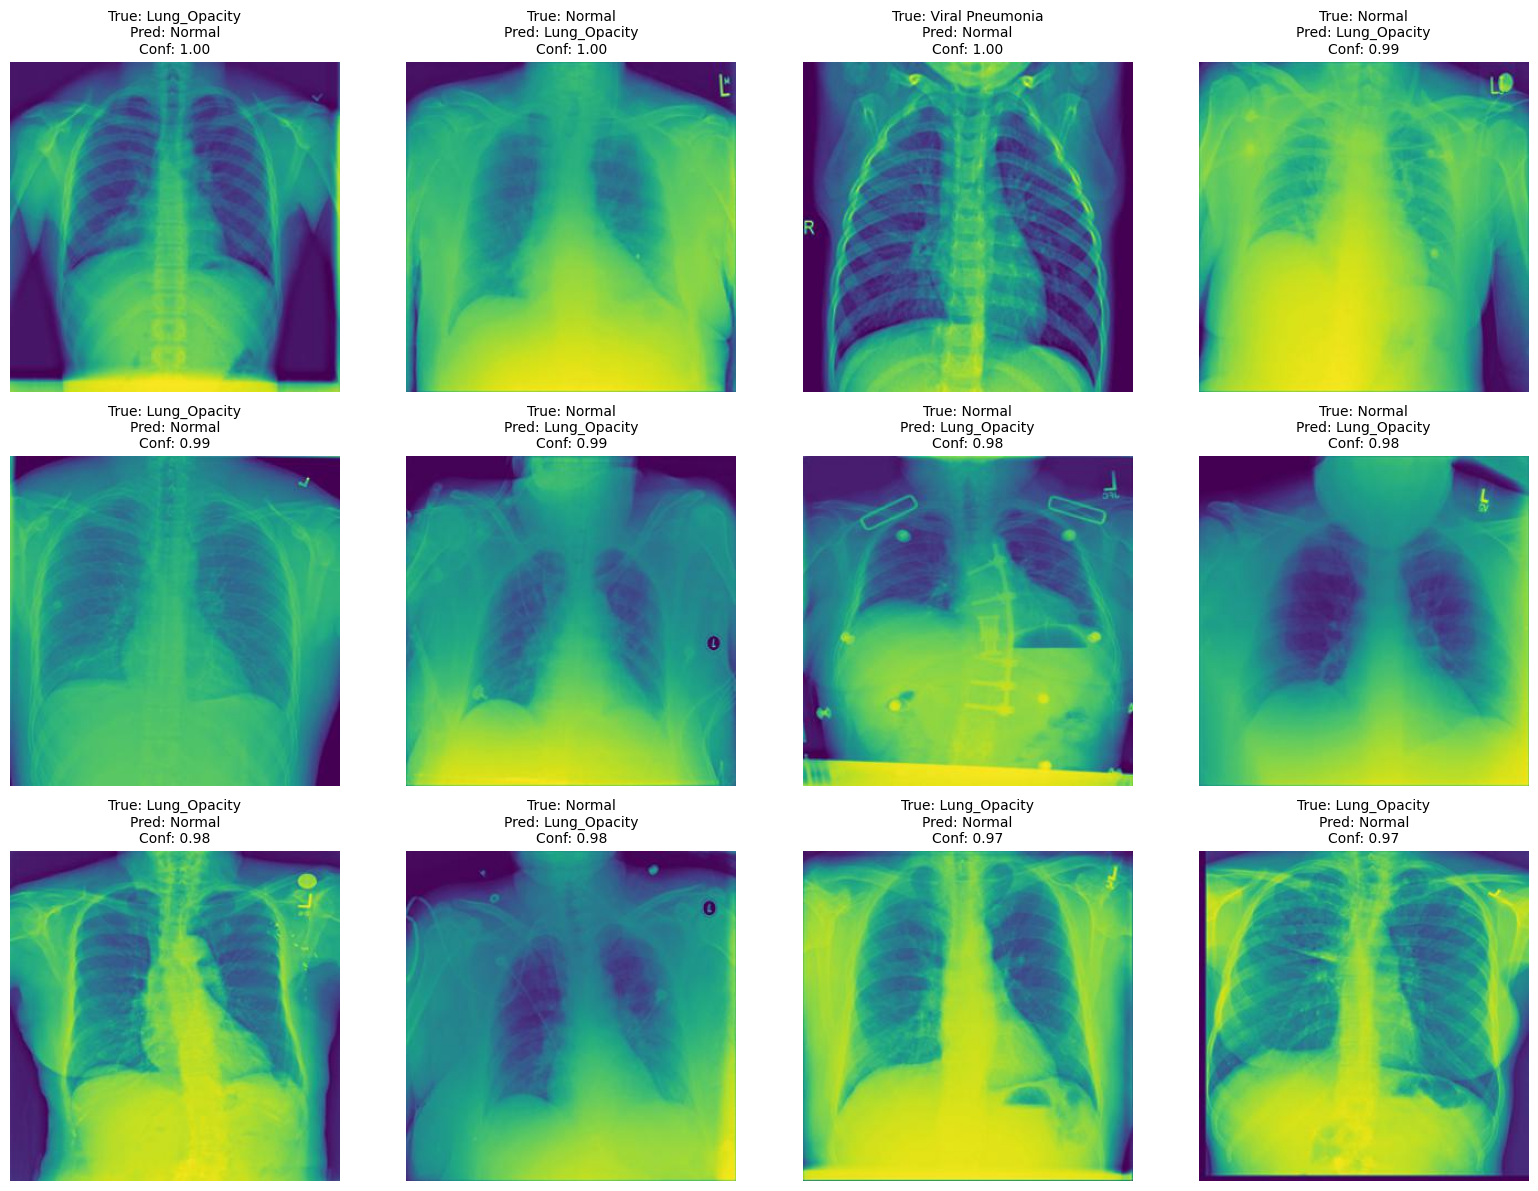

In [40]:
def show_prediction_grid(dataframe, max_images=12):
    if len(dataframe) == 0:
        print("No images to display.")
        return

    sample_df = dataframe.head(max_images)

    cols = 4
    rows = math.ceil(len(sample_df) / cols)

    plt.figure(figsize=(cols * 4, rows * 4))

    for idx, (_, row) in enumerate(sample_df.iterrows(), start=1):
        img = Image.open(row["filepath"]).convert("RGB")

        plt.subplot(rows, cols, idx)
        plt.imshow(img)
        plt.axis("off")

        title = (
            f"True: {row['true_label']}\n"
            f"Pred: {row['pred_label']}\n"
            f"Conf: {row['confidence']:.2f}"
        )

        plt.title(title, fontsize=10)

    plt.tight_layout()
    plt.show()


show_prediction_grid(
    misclassified_df,
    max_images=12
)

## 30. Visualize Correct High-Confidence Predictions 

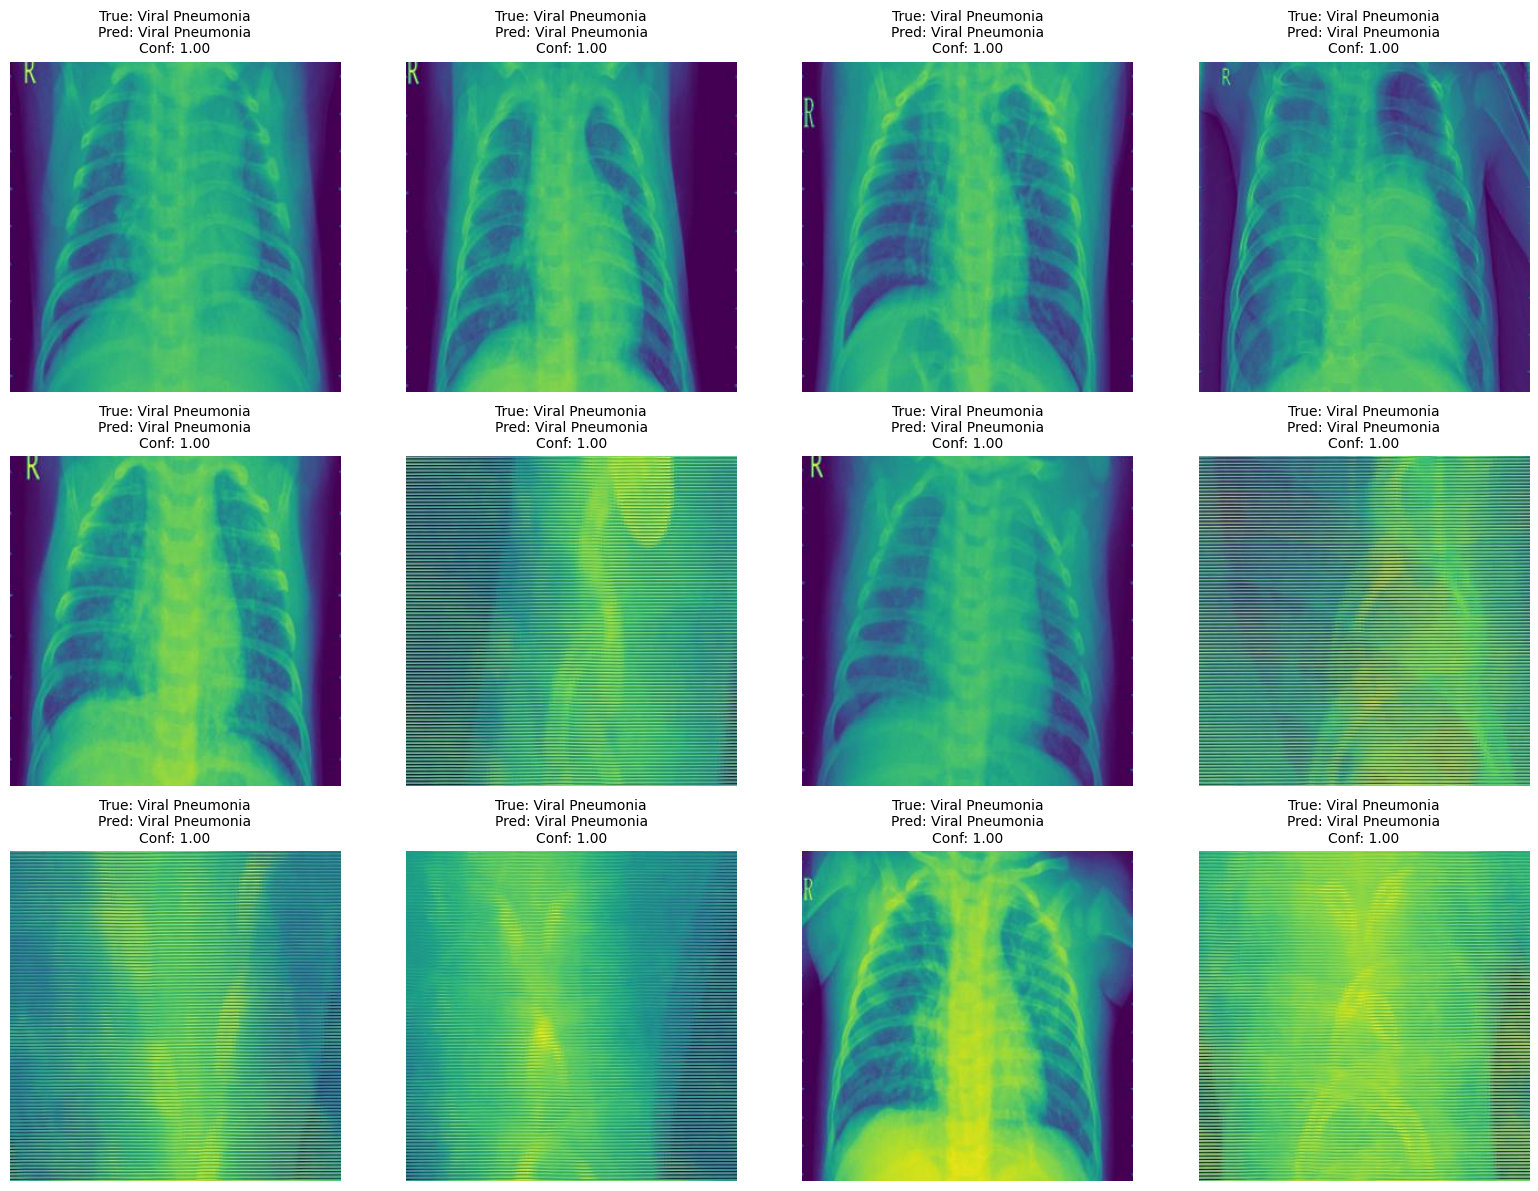

In [41]:
correct_df = (
    error_df[error_df["is_correct"] == True]
    .sort_values("confidence", ascending=False)
)

show_prediction_grid(
    correct_df,
    max_images=12
)

## 31. Single Image Inference Function 

{
    "image_path": "/kaggle/input/datasets/fatemehmehrparvar/lung-disease/Lung X-Ray Image/Lung X-Ray Image/Normal/1082.jpg",
    "predicted_label": "Normal",
    "confidence": 0.9735633134841919,
    "probabilities": {
        "Lung_Opacity": 0.02623887173831463,
        "Normal": 0.9735633134841919,
        "Viral Pneumonia": 0.00019772752420976758
    }
}


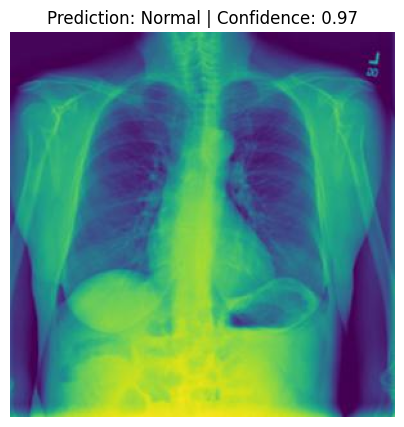

In [42]:
def predict_single_image(
    model,
    image_path,
    class_names,
    image_size=CONFIG["IMAGE_SIZE"]
):
    image = Image.open(image_path).convert("RGB")
    image_resized = image.resize(image_size)

    array = np.array(image_resized).astype(np.float32)

    if CONFIG["MODEL_NAME"] == "resnet50":
        array = keras.applications.resnet50.preprocess_input(array)

    array = np.expand_dims(array, axis=0)

    probabilities = model.predict(array, verbose=0)[0]

    pred_id = int(np.argmax(probabilities))
    pred_label = class_names[pred_id]
    confidence = float(probabilities[pred_id])

    result = {
        "image_path": image_path,
        "predicted_label": pred_label,
        "confidence": confidence,
        "probabilities": {
            class_names[i]: float(probabilities[i])
            for i in range(len(class_names))
        }
    }

    return result


example_path = test_df.sample(
    1,
    random_state=SEED
)["filepath"].iloc[0]

prediction = predict_single_image(
    best_model,
    example_path,
    class_names
)

print(json.dumps(prediction, indent=4))

img = Image.open(example_path).convert("RGB")

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off")
plt.title(
    f"Prediction: {prediction['predicted_label']} | "
    f"Confidence: {prediction['confidence']:.2f}"
)
plt.show()

## 32. Save Final Model and Label Map 

In [43]:
final_model_path = f"{CONFIG['OUTPUT_DIR']}/{CONFIG['MODEL_NAME']}_final.keras"
label_map_path = f"{CONFIG['OUTPUT_DIR']}/label_map.json"

best_model.save(final_model_path)

with open(label_map_path, "w") as f:
    json.dump(
        {
            "class_to_id": class_to_id,
            "id_to_class": id_to_class
        },
        f,
        indent=4
    )

print("Saved final model to:")
print(final_model_path)

print("Saved label map to:")
print(label_map_path)

Saved final model to:
/kaggle/working/lung_xray_project/efficientnetb0_final.keras
Saved label map to:
/kaggle/working/lung_xray_project/label_map.json
